# 1. Problem Statement

## 1.1 Justify the choice of the dataset

The dataset selected for this analysis is the third dataset about AI adoption in organisations. Compared with the other datasets, this dataset contains more business-related variables and provides a broader perspective on organisational performance, workforce transformation, governance practices, and AI implementation. It includes 43 columns with information related to AI adoption rate, AI maturity, employee training, productivity change, revenue growth, innovation score, and risk management.

Compared with the second dataset about music, the AI adoption dataset is more suitable for machine learning and business analytics because the music dataset contains fewer business-related variables and is less relevant to organisational analysis. In addition, the second dataset has a relatively small volume of data, which limits the effectiveness and reliability of machine learning analysisand reduces the generalisability of the analytical results across different organisational contexts. Therefore, the third dataset provides greater analytical potential and more meaningful relationships between variables for this research.

Another reason for choosing this dataset is that it contains more meaningful relationships between variables. For example, the dataset allows the analysis of how organisational maturity，AI investment, employee training and governance practices may influence the success of AI implementation. This makes the dataset highly suitable for exploring real-world business problems and generating practical managerial recommendations.

Therefore, the third dataset was selected because it provides richer analytical potential, clearer business objectives, and more opportunities for meaningful data-driven analysis.

## 1.2 Define the research problem

Based on the existing data, this study will apply data analytics and machine learning techniques to explore the relationships between organisational factors and AI implementation outcomes. Although many companies are increasingly adopting AI technologies, successful implementation is not guaranteed. Some organisations achieve significant improvements in productivity, innovation, and revenue growth, while others experience limited benefits or high project failure rates. Visualisation methods will also be used to present key patterns and trends more clearly. The purpose of this analysis is to identify the main drivers of successful AI implementation and provide practical recommendations for organisations adopting AI technologies.

The research problem could be defined as follows:

Research Question: What are the key factors that influence successful AI implementation in organisations?

##1.3 Explain the characteristics of the dataset

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



In [4]:
df = pd.read_csv('DATASET3_ADOPTION_IA.csv')
df.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  object 
 13 

###1.3.1 Data type

The dataset is a .csv file, which can be displayed in a table form, so it is structured data.

###1.3.2 Variables

There are 43 columns of data in total in this dataset, with each row representing a company survey observation related to AI adoption and organisational performance. For example, variables such as ai_adoption_rate and productivity_change_percent are numerical variables, while variables such as industry, company_size, and ai_adoption_stage are categorical variables.

Variables such as industry, company_size, and ai_ethics_committee are not numerical variables, so they need to be converted into numerical formats later for correlation analysis and machine learning modelling.

##1.4 Data cleaning and preprocessing

In [6]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0


In [7]:
# Check duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In this study, successful AI implementation will be measured using variables such as productivity_change_percent, revenue_growth_percent, cost_reduction_percent, and innovation_score. Factors including AI maturity, employee training, AI investment, governance practices, and risk management will be analysed to determine their influence on organisational performance.

In [20]:
ai_capability_cols = [
    'ai_adoption_rate',
    'ai_maturity_score',
    'years_using_ai',
    'num_ai_tools_used',
    'ai_projects_active'
]

# Display the selected variables
df[ai_capability_cols].head()

,ai_adoption_rate,ai_maturity_score,years_using_ai,num_ai_tools_used,ai_projects_active
0,30.57,0.224,3,1,3
1,27.25,0.174,4,3,0
2,31.54,0.266,2,3,3
3,11.02,0.123,2,1,2
4,33.39,0.363,7,3,5


In [21]:
# Check descriptive statistics
df[ai_capability_cols].describe()

,ai_adoption_rate,ai_maturity_score,years_using_ai,num_ai_tools_used,ai_projects_active
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,36.414726,0.344675,4.931580,2.315120,6.270693
std,14.544096,0.133820,2.429316,0.946826,3.500142
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,26.430000,0.250000,3.000000,2.000000,4.000000
50%,36.320000,0.341000,5.000000,2.000000,6.000000
75%,46.200000,0.435000,7.000000,3.000000,9.000000
max,100.000000,0.904000,10.000000,6.000000,20.000000


The AI capability variables were standardised because they are measured on different scales and units. For example, `years_using_ai` is measured in years, while `ai_adoption_rate` and `ai_maturity_score` are percentage or index-based variables. Without standardisation, variables with larger numerical ranges may have a disproportionate influence on correlation analysis and machine learning models.

Therefore, standardisation was applied using `StandardScaler`, which transforms the variables into a comparable scale with a mean close to 0 and a standard deviation close to 1.

In [13]:
# Import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [14]:


scaler = MinMaxScaler()

# Create new normalised columns
normalised_values = scaler.fit_transform(df[ai_capability_cols])

normalised_col_names = [col + '_normalised' for col in ai_capability_cols]

df[normalised_col_names] = normalised_values

In [16]:
# Check descriptive statistics after normalisation
df[normalised_col_names].head()

,ai_adoption_rate_normalised,ai_maturity_score_normalised,years_using_ai_normalised,num_ai_tools_used_normalised,ai_projects_active_normalised
0,0.3057,0.247788,0.3,0.0,0.15
1,0.2725,0.192478,0.4,0.4,0.00
2,0.3154,0.294248,0.2,0.4,0.15
3,0.1102,0.136062,0.2,0.0,0.10
4,0.3339,0.401549,0.7,0.4,0.25


##2. Analysis

###2.1 AI Capability Factors

The correlation analysis is used to explore whether stronger AI capability is associated with better organisational performance outcomes. The selected organisational performance indicators include productivity improvement, revenue growth, innovation capability, and cost reduction.

In [24]:
# AI capability factors
capability_cols = [
    'ai_adoption_rate_normalised',
    'ai_maturity_score_normalised',
    'years_using_ai_normalised',
    'num_ai_tools_used_normalised',
    'ai_projects_active_normalised'
]

# Organisational performance indicators
performance_cols = [
    'productivity_change_percent',
    'revenue_growth_percent',
    'innovation_score',
    'cost_reduction_percent'
]

# Correlation between capability and performance
corr_matrix = df[capability_cols + performance_cols].corr()

# Only keep capability vs performance
corr_subset = corr_matrix.loc[capability_cols, performance_cols]

corr_subset

,productivity_change_percent,revenue_growth_percent,innovation_score,cost_reduction_percent
ai_adoption_rate_normalised,0.674973,0.406839,0.509864,0.404302
ai_maturity_score_normalised,0.737314,0.403190,0.531790,0.386162
years_using_ai_normalised,0.116494,0.072800,0.091466,0.072870
num_ai_tools_used_normalised,0.364423,0.216696,0.274924,0.218866
ai_projects_active_normalised,0.566833,0.299728,0.412083,0.289453


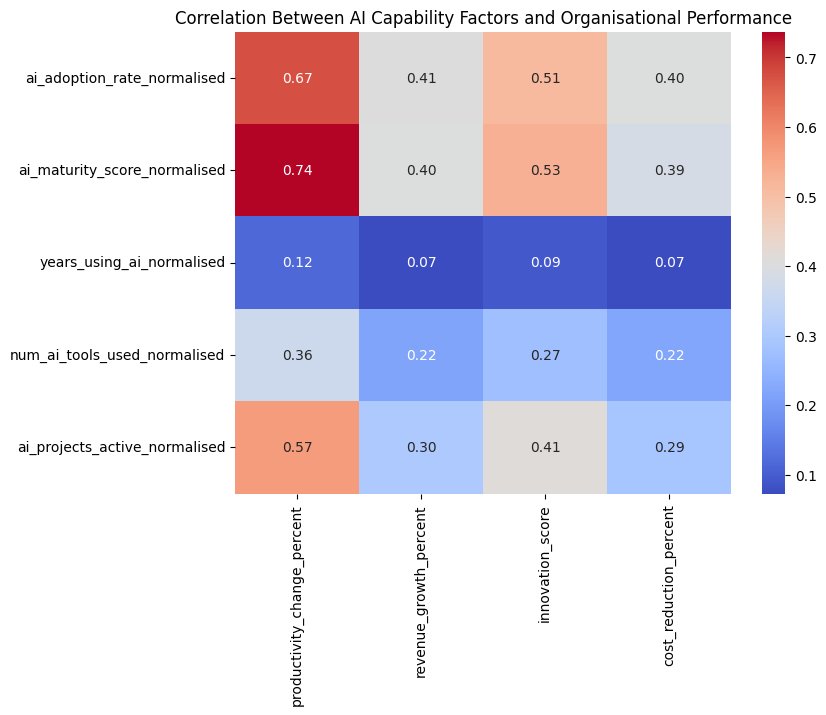

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_subset,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between AI Capability Factors and Organisational Performance')

plt.show()

The results suggest that AI maturity is one of the strongest factors associated with successful AI implementation. Organisations with higher AI maturity tend to achieve greater productivity improvement and stronger innovation performance.

In [27]:
# ==================================================
# Group Comparison by AI Adoption Stage

stage_performance = df.groupby('ai_adoption_stage')[performance_cols].mean()

stage_performance

,productivity_change_percent,revenue_growth_percent,innovation_score,cost_reduction_percent
ai_adoption_stage,,,,
full,19.792315,10.491941,67.283680,8.588315
none,2.391995,0.500773,46.649096,2.188411
partial,12.026603,6.149891,58.284594,5.770517
pilot,6.165857,2.893164,51.795124,3.757529


The boxplots compare organisational outcomes across different AI adoption stages. This helps assess whether organisations at more advanced AI adoption stages tend to achieve stronger productivity improvement and innovation performance.

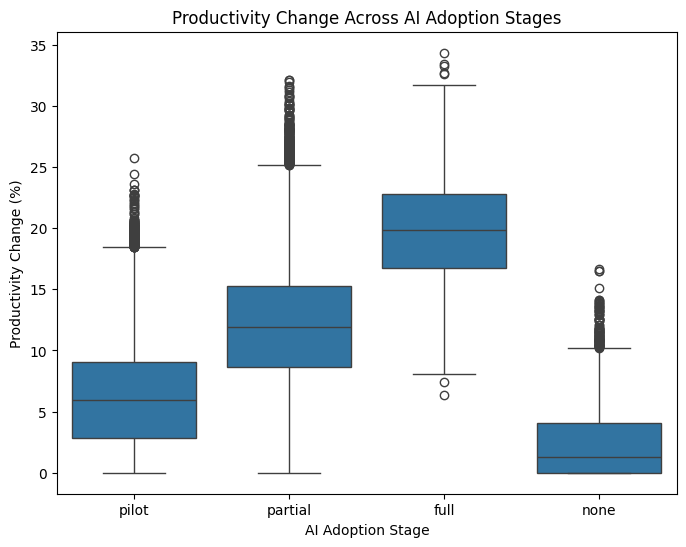

In [28]:
# Visualise productivity change by AI adoption stage

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='ai_adoption_stage',
    y='productivity_change_percent'
)

plt.title('Productivity Change Across AI Adoption Stages')
plt.xlabel('AI Adoption Stage')
plt.ylabel('Productivity Change (%)')

plt.show()

The scatterplots are used to examine whether higher AI maturity and stronger AI adoption are associated with greater productivity improvement. This supports the analysis of whether AI capability contributes to successful AI implementation.

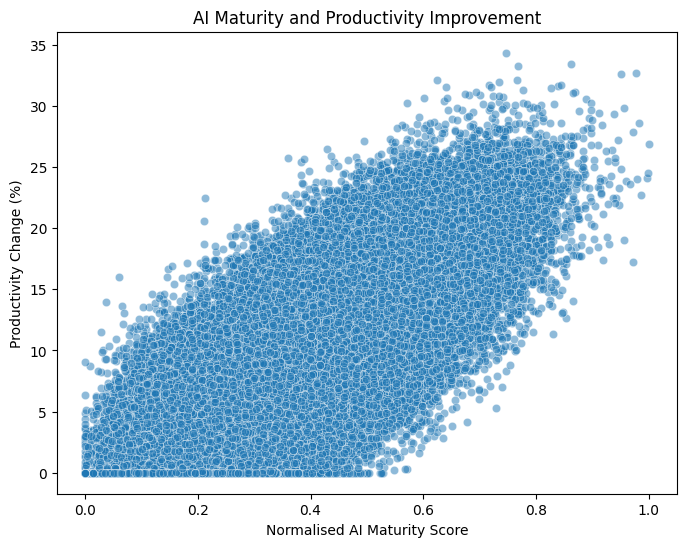

In [31]:
# ==================================================
# Scatterplot Analysis
# ==================================================

# AI maturity and productivity improvement

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='ai_maturity_score_normalised',
    y='productivity_change_percent',
    alpha=0.5
)

plt.title('AI Maturity and Productivity Improvement')
plt.xlabel('Normalised AI Maturity Score')
plt.ylabel('Productivity Change (%)')

plt.show()

The regression model is used to estimate the influence of AI capability factors on productivity improvement. The coefficients indicate which capability factors are more strongly associated with successful AI implementation. A positive coefficient suggests that an increase in the factor is associated with higher productivity improvement, while a negative coefficient suggests the opposite.

In [33]:
# ==================================================
# Regression Analysis
# ==================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define independent variables and target variable
X = df[capability_cols]
y = df['productivity_change_percent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 3))

R² Score: 0.557
Mean Absolute Error: 3.001


In [34]:
# Display regression coefficients

capability_coefficients = pd.DataFrame({
    'AI Capability Factor': capability_cols,
    'Coefficient': model.coef_
})

capability_coefficients = capability_coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

capability_coefficients

,AI Capability Factor,Coefficient
1,ai_maturity_score_normalised,23.303660
0,ai_adoption_rate_normalised,6.930723
3,num_ai_tools_used_normalised,0.000462
2,years_using_ai_normalised,-0.226745
4,ai_projects_active_normalised,-0.930780


###2.2 Investment & Training Factors

In [38]:
# ==================================================
# Investment & Training Factors
# ==================================================

# Select investment and training variables
investment_training_cols = [
    'ai_budget_percentage',
    'ai_investment_per_employee',
    'ai_training_hours',
    'reskilled_employees'
]

# Display the selected variables
df[investment_training_cols].head()

,ai_budget_percentage,ai_investment_per_employee,ai_training_hours,reskilled_employees
0,6.54,55392.29,20.94,3
1,5.81,49210.79,23.10,5
2,12.39,105011.76,12.29,2
3,3.20,27157.71,11.31,2
4,9.98,84622.90,35.17,6


In [39]:
# Create scaler
scaler = MinMaxScaler()

# Apply normalisation
normalised_values = scaler.fit_transform(df[investment_training_cols])

# Create new column names
investment_training_normalised_cols = [
    col + '_normalised' for col in investment_training_cols
]

# Add normalised variables into dataframe
df[investment_training_normalised_cols] = normalised_values

# Display normalised variables
df[investment_training_normalised_cols].head()

,ai_budget_percentage_normalised,ai_investment_per_employee_normalised,ai_training_hours_normalised,reskilled_employees_normalised
0,0.2616,0.029180,0.261750,0.000773
1,0.2324,0.025923,0.288750,0.001288
2,0.4956,0.055318,0.153625,0.000515
3,0.1280,0.014306,0.141375,0.000515
4,0.3992,0.044578,0.439625,0.001546


In [40]:
# ==================================================
# Correlation Analysis
# ==================================================

# Organisational performance indicators
performance_cols = [
    'productivity_change_percent',
    'revenue_growth_percent',
    'innovation_score',
    'cost_reduction_percent'
]

# Correlation matrix
corr_matrix = df[
    investment_training_normalised_cols + performance_cols
].corr()

# Keep only investment/training vs performance
corr_subset = corr_matrix.loc[
    investment_training_normalised_cols,
    performance_cols
]

corr_subset

,productivity_change_percent,revenue_growth_percent,innovation_score,cost_reduction_percent
ai_budget_percentage_normalised,0.604105,0.340629,0.445472,0.328713
ai_investment_per_employee_normalised,0.218707,0.121861,0.161687,0.117579
ai_training_hours_normalised,0.633740,0.347841,0.444496,0.328314
reskilled_employees_normalised,0.282751,0.148254,0.197643,0.135670


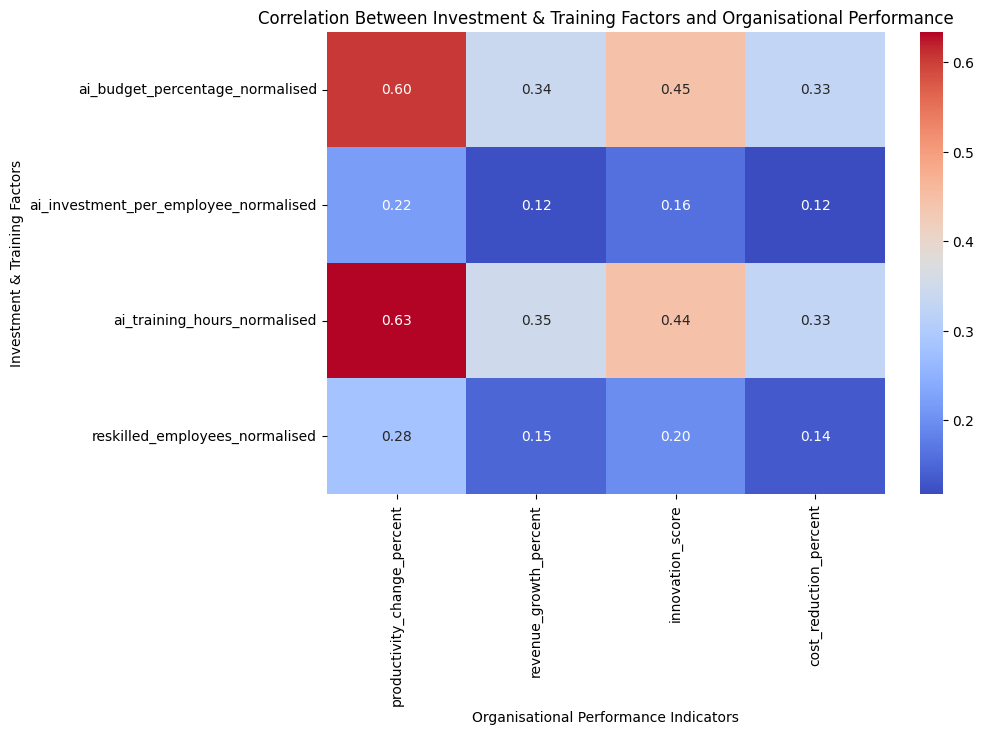

In [41]:
# Visualise correlations

plt.figure(figsize=(9,6))

sns.heatmap(
    corr_subset,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Investment & Training Factors and Organisational Performance')

plt.xlabel('Organisational Performance Indicators')
plt.ylabel('Investment & Training Factors')

plt.show()

In [42]:
# ==================================================
# Regression Analysis
# ==================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define independent variables and target variable

X = df[investment_training_normalised_cols]

y = df['productivity_change_percent']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build regression model

model = LinearRegression()

model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Model evaluation

print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 3))

R² Score: 0.499
Mean Absolute Error: 3.2


In [43]:
# Regression coefficients

investment_coefficients = pd.DataFrame({
    'Investment & Training Factor': investment_training_normalised_cols,
    'Coefficient': model.coef_
})

investment_coefficients = investment_coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

investment_coefficients

,Investment & Training Factor,Coefficient
2,ai_training_hours_normalised,14.596473
0,ai_budget_percentage_normalised,13.035768
3,reskilled_employees_normalised,1.207065
1,ai_investment_per_employee_normalised,0.781276


The regression analysis is conducted to evaluate which investment and training factors contribute most strongly to productivity improvement. The coefficients indicate the relative influence of AI investment, employee training, and workforce reskilling on successful AI implementation.

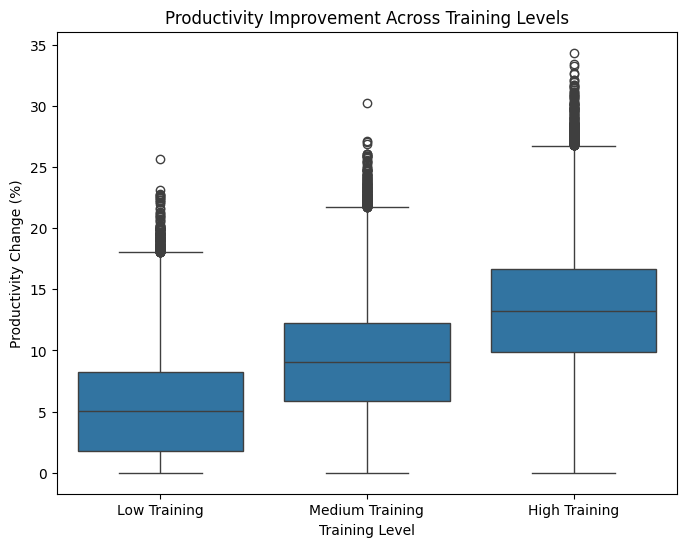

In [45]:
# ==================================================
# Group Comparison
# ==================================================

# Create training level groups

df['training_level'] = pd.qcut(
    df['ai_training_hours'],
    q=3,
    labels=['Low Training', 'Medium Training', 'High Training']
)

# Compare productivity across training groups

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='training_level',
    y='productivity_change_percent'
)

plt.title('Productivity Improvement Across Training Levels')

plt.xlabel('Training Level')
plt.ylabel('Productivity Change (%)')

plt.show()

##3. Visualization

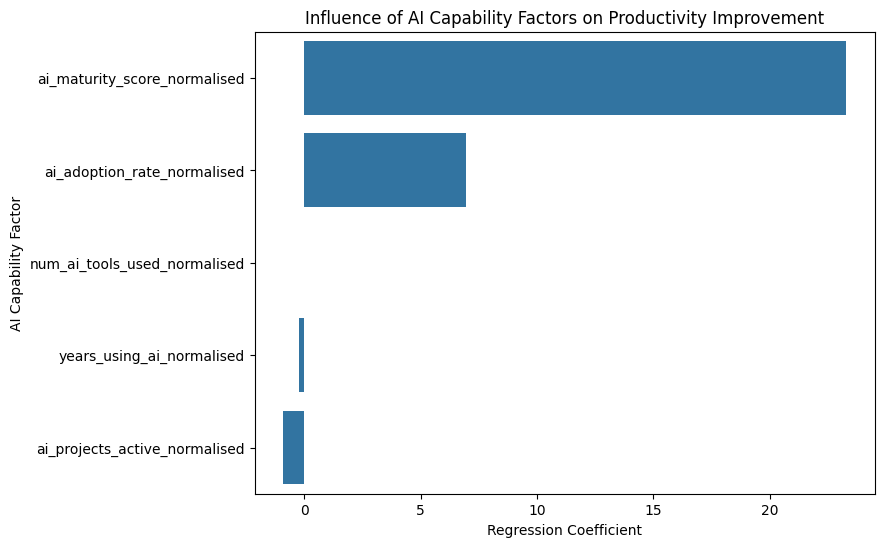

In [35]:
# Visualise regression coefficients

plt.figure(figsize=(8, 6))

sns.barplot(
    data=capability_coefficients,
    x='Coefficient',
    y='AI Capability Factor'
)

plt.title('Influence of AI Capability Factors on Productivity Improvement')
plt.xlabel('Regression Coefficient')
plt.ylabel('AI Capability Factor')

plt.show()

The regression results indicate that AI maturity is the strongest capability factor influencing productivity improvement. In contrast, simply using AI for a longer period or increasing the number of AI tools does not necessarily lead to successful AI implementation.
AI expansion may create operational complexity if implementation is not effectively managed.

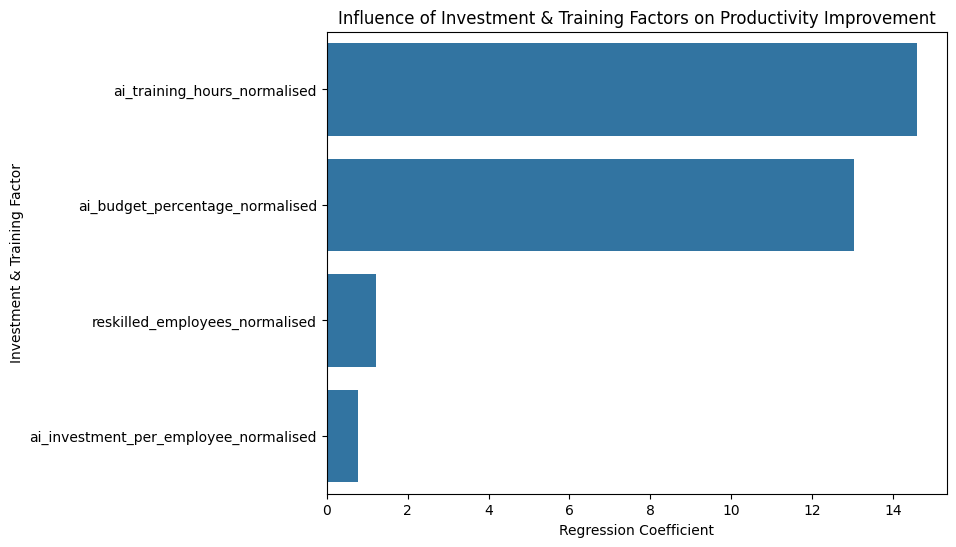

In [44]:
# Visualise regression coefficients

plt.figure(figsize=(8,6))

sns.barplot(
    data=investment_coefficients,
    x='Coefficient',
    y='Investment & Training Factor'
)

plt.title('Influence of Investment & Training Factors on Productivity Improvement')

plt.xlabel('Regression Coefficient')
plt.ylabel('Investment & Training Factor')

plt.show()

The results suggest that employee training plays a critical role in successful AI implementation. Organisations that invest more heavily in AI-related training tend to achieve stronger productivity improvement.
Organisations should treat AI implementation as a long-term strategic investment rather than a short-term technological experiment.

##4. Conclusion & recommendation
Based on the analysis, the results suggest that successful AI implementation is influenced more by organisational capability, employee training, and strategic investment than by simple AI exposure alone. Although AI adoption rate shows a positive relationship with organisational performance, variables related to AI maturity and workforce training demonstrate a stronger influence on productivity improvement and innovation outcomes. In particular, ai_maturity_score and ai_training_hours appear to be the most important factors associated with successful AI implementation.

The analysis also indicates that simply using AI for a longer period or increasing the number of AI tools does not necessarily guarantee better organisational outcomes. This suggests that successful AI implementation depends not only on technology adoption itself, but also on how effectively AI is integrated into organisational workflows, decision-making processes, and employee capabilities. In addition, the results imply that increasing the number of active AI projects may create operational complexity if implementation is not properly managed.

From a managerial perspective, organisations should avoid treating AI implementation as a short-term technological trend. Instead, AI adoption should be approached as a long-term organisational transformation strategy. Companies should focus on improving AI maturity through structured implementation, workflow integration, and continuous capability development rather than simply expanding AI usage.

The findings also highlight the importance of workforce development. Employee AI training shows one of the strongest relationships with productivity improvement, suggesting that organisations should invest more resources into training, reskilling, and AI literacy development. Without sufficient workforce preparation, AI technologies may fail to generate sustainable organisational value.

However, these decisions may also create challenges for certain stakeholders. For example, increasing automation and AI-driven operational efficiency could lead to workforce displacement and concerns regarding job security. While AI implementation may improve organisational productivity, it may also negatively affect employees whose tasks become automated. Therefore, organisations should balance productivity goals with responsible workforce transition strategies, including reskilling programmes and internal redeployment opportunities.

Due to time limitations, governance and risk management factors were not fully analysed in this study. Nevertheless, these variables remain highly important for successful AI implementation. Variables such as regulatory_compliance_score, data_privacy_level, ai_ethics_committee, and ai_risk_management_score suggest that governance maturity may play a significant role in ensuring sustainable and ethical AI adoption. Organisations that neglect data privacy, regulatory compliance, and AI risk management may experience operational risks, ethical concerns, or implementation failures even if AI capability and investment levels are high.



Therefore, organisations should establish clear AI governance frameworks, including stronger data privacy protection, AI ethics oversight, and risk management mechanisms. AI implementation should not focus solely on operational efficiency, but also consider transparency, accountability, and stakeholder trust.

Overall, the analysis suggests that successful AI implementation is primarily influenced by organisational AI maturity, employee training, strategic investment, and effective implementation capability. While AI adoption itself is important, long-term success depends more on organisational readiness, workforce adaptation, and responsible governance practices. Therefore, the key factors that influence successful AI implementation in organisations are not only technological capability, but also the ability to integrate AI into organisational structures, employee development, and sustainable managerial practices.